In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
path = "/content/drive/MyDrive/Technical Content/data/"

In [24]:
import os
import pandas as pd
import numpy as np

files = {
"Ethiopia":"ethiopia.csv",
"Kenya":"kenya.csv",
"Nigeria":"nigeria.csv",
"Sudan":"sudan.csv",
"Tanzania":"tanzania.csv"
}

dfs = {}

for country,file in files.items():

    df = pd.read_csv(path + file)

    df["Country"] = country

    df["date"] = pd.to_datetime(
        df["YEAR"]*1000 + df["DOY"],
        format="%Y%j"
    )

    df["Month"] = df["date"].dt.month

    df.replace(-999,np.nan,inplace=True)

    dfs[country] = df

In [26]:
for c,df in dfs.items():
    print(f"\n{c}")
    print("Missing values:")
    print(df.isna().sum().sum())

    print("Duplicates:")
    print(df.duplicated().sum())


Ethiopia
Missing values:
0
Duplicates:
0

Kenya
Missing values:
0
Duplicates:
0

Nigeria
Missing values:
0
Duplicates:
0

Sudan
Missing values:
0
Duplicates:
0

Tanzania
Missing values:
0
Duplicates:
0


In [25]:
for c,df in dfs.items():
    print(c)
    print(df[['T2M','PRECTOTCORR']].describe())

Ethiopia
              T2M  PRECTOTCORR
count  4108.00000  4108.000000
mean     16.06850     3.633795
std       1.89805     6.289061
min      10.03000     0.000000
25%      14.82000     0.020000
50%      16.04000     0.820000
75%      17.36000     4.580000
max      21.53000    82.300000
Kenya
               T2M  PRECTOTCORR
count  4108.000000  4108.000000
mean     20.427600     1.468162
std       1.440824     3.180228
min      15.260000     0.000000
25%      19.460000     0.100000
50%      20.360000     0.380000
75%      21.400000     1.360000
max      25.400000    51.650000
Nigeria
               T2M  PRECTOTCORR
count  4108.000000  4108.000000
mean     26.656928     4.213914
std       1.123335     7.266742
min      21.120000     0.000000
25%      25.720000     0.330000
50%      26.820000     1.840000
75%      27.540000     5.200000
max      29.290000   166.100000
Sudan
               T2M  PRECTOTCORR
count  4108.000000  4108.000000
mean     28.759007     0.643875
std       4.681305  

In [27]:
from scipy.stats import zscore
import numpy as np

cols=['T2M','PRECTOTCORR']

for c,df in dfs.items():
    z=np.abs(zscore(df[cols]))
    print(c)
    print((z>3).sum(axis=0))

Ethiopia
[ 3 95]
Kenya
[ 8 92]
Nigeria
[10 75]
Sudan
[ 3 71]
Tanzania
[ 1 81]


Nigeria and Kenya show relatively more temperature outliers, while Ethiopia and Kenya show more precipitation extremes. This suggests vulnerability differs across countries, with some exposed more to heat anomalies and others to rainfall extremes.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

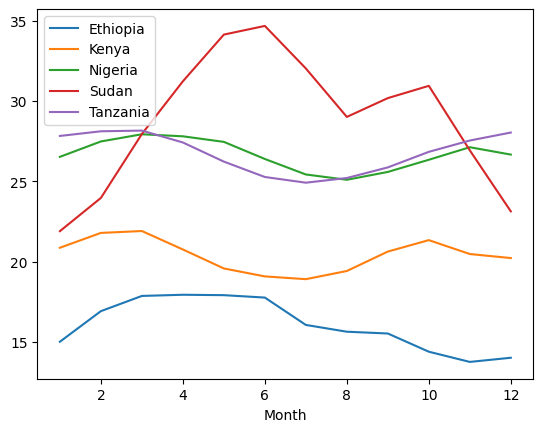

In [33]:
for c,df in dfs.items():
    df.groupby('Month')['T2M'].mean().plot(label=c)

plt.legend()

Sudan has the highest average temperatures (28.76°C), followed by Tanzania and Nigeria, while Ethiopia has the lowest (16.07°C). This indicates major differences in heat exposure across countries, with Sudan facing substantially greater thermal stress than its neighbors.

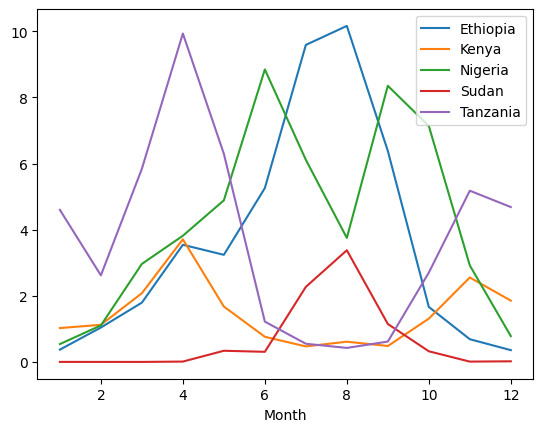

In [34]:
for c,df in dfs.items():
    df.groupby('Month')['PRECTOTCORR'].mean().plot(label=c)

plt.legend()

Nigeria and Tanzania show the highest precipitation variability, with intense rainfall extremes, while Sudan shows persistently low rainfall, indicating chronic aridity. Kenya exhibits relatively low average rainfall but notable dry conditions, suggesting drought vulnerability.

In [30]:
for c,df in dfs.items():
    print(c,(df["T2M_MAX"]>30).sum())

Ethiopia 18
Kenya 796
Nigeria 910
Sudan 3806
Tanzania 1176


Sudan consistently exhibits the highest temperatures across months, while Ethiopia remains coolest. Tanzania and Nigeria show similarly warm climates, whereas Kenya occupies an intermediate position. This highlights differing levels of exposure to warming stress across the region.

In [31]:
for c,df in dfs.items():
    print(c,(df["PRECTOTCORR"]<1).sum())

Ethiopia 2161
Kenya 2831
Nigeria 1595
Sudan 3696
Tanzania 2303


Temperature differences across countries are statistically significant (p < 0.05), indicating observed variations in climate conditions are unlikely due to chance.